# Hybrid AutoEncoder + DeepResNet for Student Performance Prediction

This notebook implements a complete pipeline for predicting student performance using the OULAD dataset.

Pipeline:
- Data preprocessing and feature engineering
- Representation learning using AutoEncoder
- Classification using Deep Residual Network
- Evaluation using advanced metrics (ROC, PR)

Reproducibility ensured via fixed random seed.

# Imports + Configuration


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
    roc_auc_score, precision_recall_curve,
    average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

# 0. Reproductibilité & configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set(style="whitegrid")


Device: cpu


## Part 1 - Data Preprocessing





### Loading Data

In [4]:
# Paths & output directories
data_path = "/content/drive/MyDrive/open+university+learning+analytics+dataset"
out_dir = Path("eda_outputs")
out_dir.mkdir(exist_ok=True)

In [5]:
# Loading data
studentInfo = pd.read_csv(f"{data_path}/studentInfo.csv")
studentVle  = pd.read_csv(f"{data_path}/studentVle.csv")

studentInfo['id_student'] = studentInfo['id_student'].astype(int)
studentVle['id_student']  = studentVle['id_student'].astype(int)
studentVle['sum_click']   = pd.to_numeric(
    studentVle['sum_click'], errors='coerce').fillna(0)

### Exploratory Data Analysis

=== OVERVIEW: studentInfo ===
Shape: (32593, 12)
Columns dtypes:
 code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object

Missing values (top 20):
code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64

Examples:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn



---

=== OVERVIEW: studentVle ===
Shape: (10655280, 6)
Columns dtypes:
 code_module          object
code_presentation    object
id_student            int64
id_site               int64
date                  int64
sum_click             int64
dtype: object

Missing values (top 20):
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

Examples:


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1



---



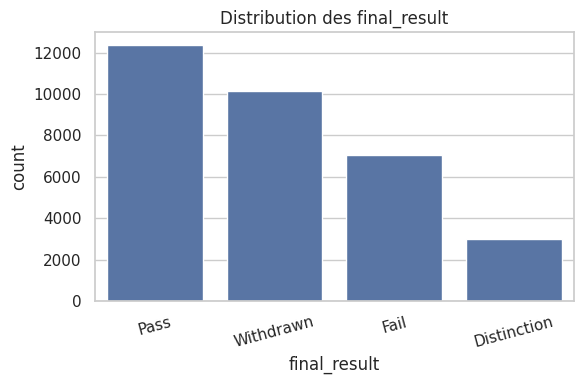

In [6]:
# This section provides a general overview of the datasets.
# It helps understand data structure, detect missing values,
# and inspect sample records before further preprocessing.

def overview(df, name):
    # Print dataset name for clarity
    print(f"=== OVERVIEW: {name} ===")
    # Display dataset dimensions (rows, columns)
    print("Shape:", df.shape)
    # Show data types of each column
    print("Columns dtypes:\n", df.dtypes)
    # Identify missing values (top 20 columns with most missing data)
    print("\nMissing values (top 20):")
    print(df.isna().sum().sort_values(ascending=False).head(20))
    # Display first few rows for quick inspection
    print("\nExamples:")
    try:
        display(df.head(3))
    except NameError:
        print(df.head(3))
    print("\n---\n")

# Apply overview function to both datasets
overview(studentInfo, "studentInfo")
overview(studentVle,  "studentVle")

# Target Variable Distribution

# This plot shows the distribution of the target variable (final_result),
# which represents student outcomes (e.g., Withdrawn, Fail, Pass, Distinction).
# It is useful to detect class imbalance before training models.
plt.figure(figsize=(6, 4))
sns.countplot(
    data=studentInfo, x='final_result',
    order=studentInfo['final_result'].value_counts().index
)
# Plot formatting
plt.title("Distribution des final_result")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(out_dir / "final_result_distribution.png")
plt.show()

### Descriptive Statistics and Categorical Feature Distribution

,count,mean,std,min,25%,50%,75%,max
id_student,32593.0,706687.669131,549167.313855,3733.0,508573.0,590310.0,644453.0,2716795.0
num_of_prev_attempts,32593.0,0.163225,0.479758,0.0,0.0,0.0,0.0,6.0
studied_credits,32593.0,79.758691,41.071900,30.0,60.0,60.0,120.0,655.0


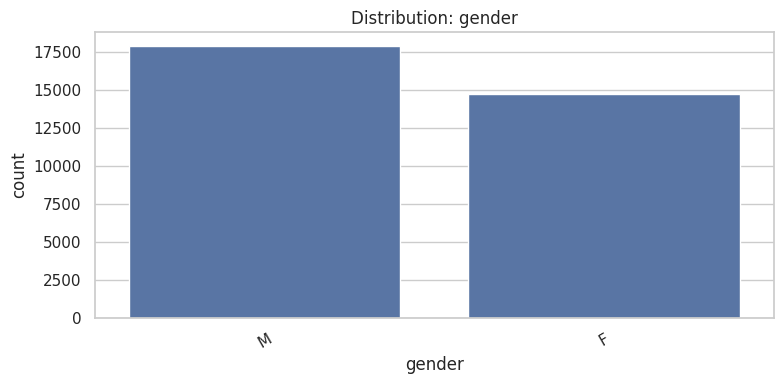

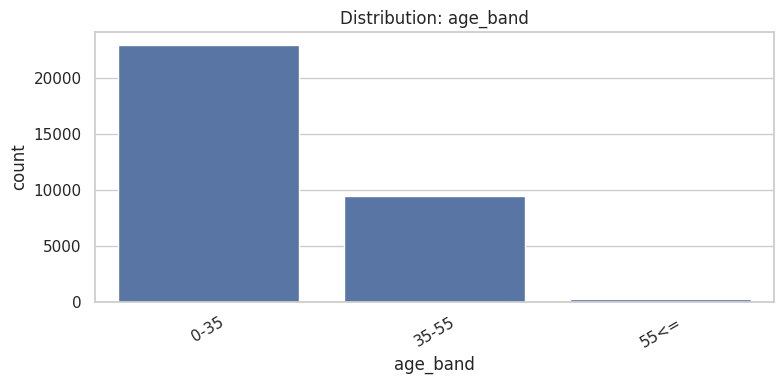

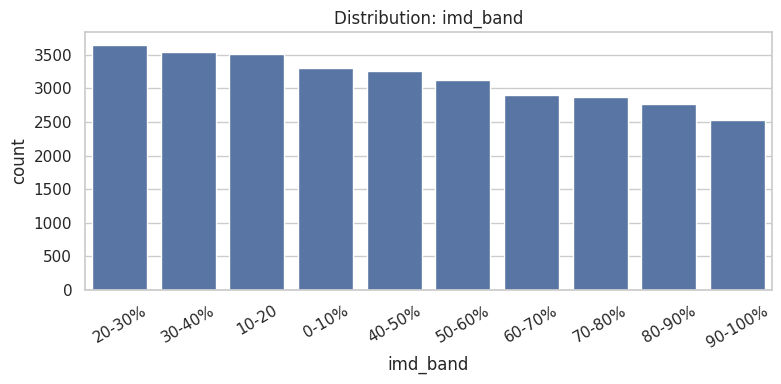

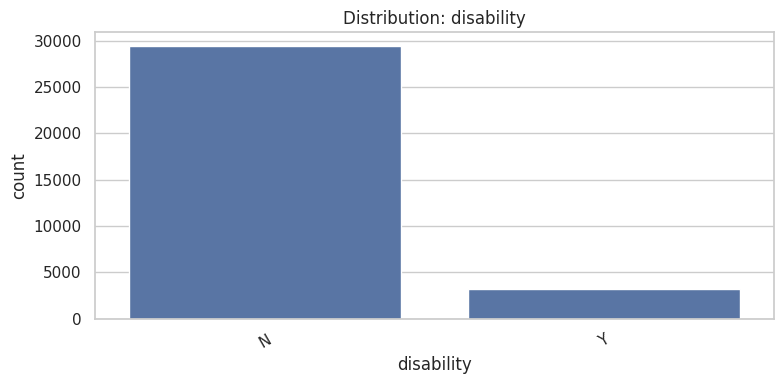

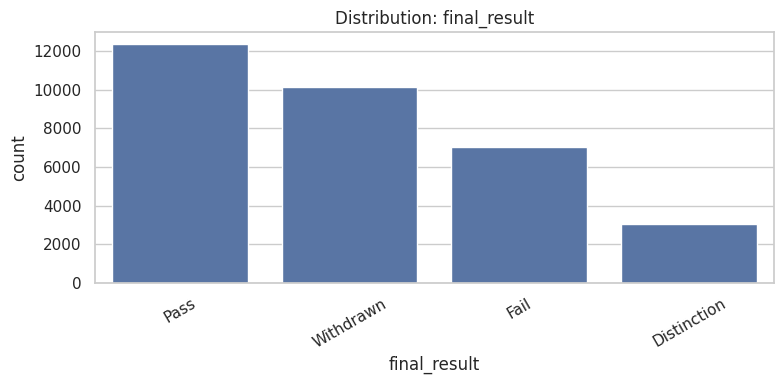

In [7]:
# This section provides a statistical summary of numerical variables
# and analyzes the distribution of categorical features.
# It helps understand data characteristics before modeling.

# Descriptive statistics for numerical features

# Select numerical columns from the dataset
num_cols = studentInfo.select_dtypes(include=[np.number]).columns.tolist()
# Compute descriptive statistics (mean, std, min, max, quartiles)
desc = studentInfo[num_cols].describe().T

# Save statistics to CSV file for documentation and reproducibility
desc.to_csv(out_dir / "studentInfo_numeric_description.csv")
# Display the statistics table
try:
    display(desc)
except NameError:
    print(desc)

# Preprocessing categorical features

# Replace missing or unknown values in 'imd_band' column
studentInfo['imd_band'] = studentInfo['imd_band'].replace("?", np.nan)

# Distribution analysis of categorical variables
# List of categorical columns to analyze
cat_cols = ['gender', 'age_band', 'imd_band', 'disability', 'final_result']

# Plot distribution of each categorical variable
for c in cat_cols:
    if c in studentInfo.columns:
        # Create figure
        plt.figure(figsize=(8, 4))
        # Plot count distribution (ignoring missing values)
        sns.countplot(
            data=studentInfo.dropna(subset=[c]), x=c,
            order=studentInfo[c].dropna().value_counts().index
        )
        # Formatting
        plt.title(f"Distribution: {c}")
        plt.xticks(rotation=30)
        # Adjust layout and save figure
        plt.tight_layout()
        plt.savefig(out_dir / f"dist_{c}.png")
        # Display plot
        plt.show()

The distribution of the target variable (final_result) shows a clear class imbalance.
The majority of students belong to the "Pass" and "Withdrawn" categories,
while fewer students achieve "Distinction".

This imbalance highlights the need for appropriate strategies such as
class weighting during training to avoid biased predictions.

The distribution of the disability variable indicates that most students
do not report a disability, with only a small proportion belonging to the
disabled category.

This imbalance suggests that the impact of this feature may be limited
and should be carefully considered during modeling.

The IMD (Index of Multiple Deprivation) distribution appears relatively balanced
across categories, although slight variations are observed.

This suggests that socio-economic factors are reasonably represented
and may contribute meaningfully to predictive modeling.

The gender distribution is relatively balanced between male and female students,
indicating no strong gender bias in the dataset.

This balance is beneficial for building fair and unbiased predictive models.

The descriptive statistics of numerical features show that:
- The number of previous attempts is generally low, indicating that most students
  are not repeating courses.
- Studied credits exhibit variability, reflecting differences in academic workload.

These variations may play a significant role in predicting student performance.

### Learning Behavior Analysis (Clickstream Data)

,count,mean,std,min,25%,50%,75%,max
n_sites,26074.0,408.655365,430.608121,1.0,108.000000,270.000000,570.000000,6389.000000
sum,26074.0,1518.949873,1935.994635,1.0,298.000000,824.000000,2018.000000,28615.000000
mean,26074.0,3.277612,1.196497,1.0,2.382609,3.095676,4.000000,19.427536
std,26074.0,5.426368,5.068490,0.0,2.559447,4.274062,7.262038,309.454738
max,26074.0,55.394339,100.301590,1.0,17.000000,35.000000,75.000000,6977.000000


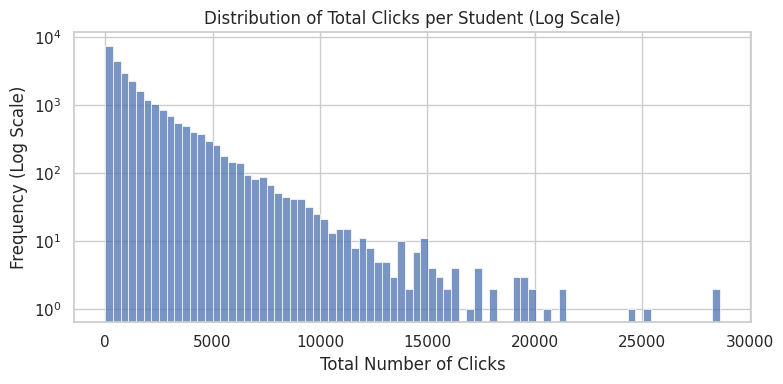

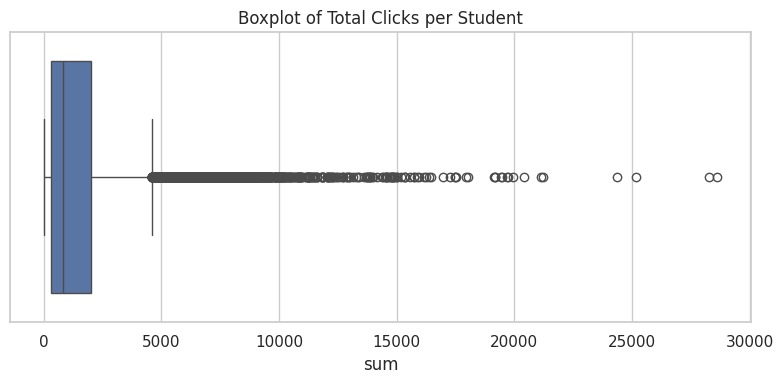

In [8]:
# Student Click Behavior Analysis

# This section analyzes student interaction behavior with learning resources.
# It aggregates clickstream data to derive engagement-related features.

# Aggregate click data per student

# For each student, compute:
# - number of accessed sites (n_sites)
# - total number of clicks (sum)
# - average clicks per interaction (mean)
# - variability of clicks (std)
# - maximum clicks on a single resource (max)

clicks_by_student = (
    studentVle.groupby('id_student')['sum_click']
    .agg(['count', 'sum', 'mean', 'std', 'max'])
    .fillna(0)
)
# Rename 'count' to 'n_sites' for clarity
clicks_by_student.rename(columns={'count': 'n_sites'}, inplace=True)
# Save aggregated features for reproducibility
clicks_by_student.to_csv(out_dir / "clicks_by_student.csv")
# Display descriptive statistics
try:
    display(clicks_by_student.describe().T)
except NameError:
    print(clicks_by_student.describe().T)

# Distribution of total clicks (log scale)
# Histogram showing the distribution of student engagement levels.
# Log scale is used due to high skewness in click counts.
plt.figure(figsize=(8, 4))
sns.histplot(
    clicks_by_student['sum'][clicks_by_student['sum'] > 0], bins=80)
plt.yscale("log")
plt.title("Distribution of Total Clicks per Student (Log Scale)")
plt.xlabel("Total Number of Clicks")
plt.ylabel("Frequency (Log Scale)")
plt.tight_layout()
plt.savefig(out_dir / "hist_clicks_total.png")
plt.show()

# Boxplot of total clicks
# Visualize dispersion and detect outliers in student engagement.

plt.figure(figsize=(8, 4))
sns.boxplot(x=clicks_by_student['sum'])
plt.title("Boxplot of Total Clicks per Student")
plt.tight_layout()
plt.savefig(out_dir / "box_clicks_total.png")
plt.show()

- The distribution of total clicks per student is highly skewed,
as shown by the histogram on a logarithmic scale.

Most students exhibit relatively low interaction levels,
while a small number of students generate a very high number of clicks.

This indicates the presence of heterogeneous engagement behaviors,
with a long-tail distribution.

- The boxplot reveals a large number of outliers corresponding to highly active students.

The median number of clicks is significantly lower than the maximum values,
confirming that a small subset of students dominates the interaction activity.

This suggests that student engagement is not uniformly distributed.

These observations motivate the use of robust modeling approaches
and representation learning techniques (e.g., AutoEncoder)
to effectively capture complex and highly skewed interaction patterns.

### Learning Resource Engagement Analysis

,count,sum,mean
id_site,,,
716238,156399,718737,4.595534
882537,157590,716869,4.548950
526721,122408,586632,4.792432
673519,120291,455896,3.789943
909013,126527,442887,3.500336
716216,139057,438037,3.150054
542807,60316,420908,6.978381
779089,90574,396097,4.373187
882545,132508,390011,2.943302


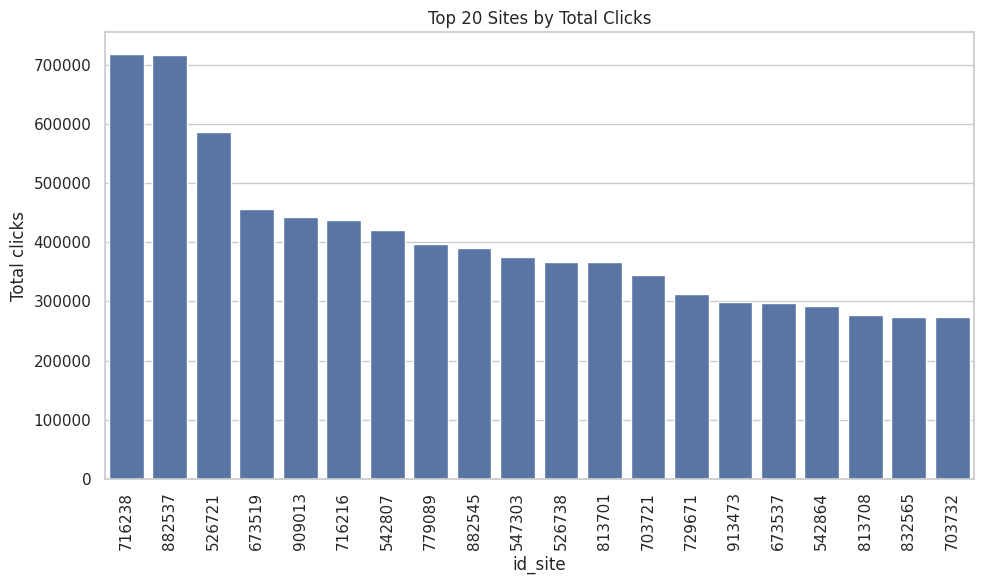

In [9]:
# This section analyzes student engagement at the learning resource level.
# Each VLE site represents a learning resource, and the number of clicks
# reflects the level of interaction with that resource.

# Aggregate click statistics for each learning resource (id_site)
site_agg = (
    studentVle.groupby('id_site')['sum_click']
    .agg(['count', 'sum', 'mean'])
    .sort_values('sum', ascending=False)
)

# Save the top 20 most accessed learning resources for reproducibility
site_agg.head(20).to_csv(out_dir / "top_sites_by_clicks.csv")
# Display the top 20 learning resources by total clicks
try:
    display(site_agg.head(20))
except NameError:
    print(site_agg.head(20))

# Visualize the top 20 learning resources according to total student clicks
plt.figure(figsize=(10, 6))
sns.barplot(
    x=site_agg.head(20).index.astype(str),
    y=site_agg.head(20)['sum']
)
# Plot formatting
plt.xticks(rotation=90)
plt.title("Top 20 Sites by Total Clicks")
plt.ylabel("Total clicks")
plt.xlabel("id_site")
# Save and display the figure
plt.tight_layout()
plt.savefig(out_dir / "top20_sites.png")
plt.show()

The analysis of the top 20 learning resources shows that student engagement is not uniformly distributed across VLE sites.

A limited number of resources receive a much higher number of clicks, suggesting that some learning materials play a more central role in student activity.

This indicates that resource-level engagement patterns may provide useful behavioral signals for predicting student outcomes.

These observations support the use of student–resource interaction data and justify the construction of a student–resource matrix for representation learning using the AutoEncoder.

### Multi-Modal Feature Engineering

In this section, we construct a comprehensive feature representation by integrating:
- Behavioral features derived from clickstream data
- Academic performance indicators
- Demographic attributes

This multi-view representation is designed to enhance predictive performance
by capturing diverse aspects of student learning behavior.

In [10]:
# Feature Engineering

# Label Encoding of Target Variable
# Mapping academic outcomes into ordinal classes
# (Withdrawn < Fail < Pass < Distinction)

label_map = {"Withdrawn": 0, "Fail": 1, "Pass": 2, "Distinction": 3}
students = studentInfo.dropna(subset=["final_result"]).copy()
students["label"] = students["final_result"].map(label_map)

# Behavioral Features (Clickstream Data)
# Aggregating student interactions with learning resources
# These features capture engagement intensity and variability

agg_clicks = (studentVle.groupby('id_student')['sum_click']
    .agg(['mean', 'std', 'max', 'sum'])
    .fillna(0)
)
agg_clicks.columns = ['click_mean', # average engagement
                      'click_std', # variability of engagement
                      'click_max', # peak activity
                      'click_sum'  # total activity
                      ]

# Academic Features
# Capturing student academic history and workload
base = (students[['id_student', 'num_of_prev_attempts', 'studied_credits', 'label']]
    .drop_duplicates('id_student')
    .set_index('id_student'))

# Normalized academic effort (credits per attempt)

base['credits_per_attempt'] = (
    base['studied_credits'] / (base['num_of_prev_attempts'] + 1)
)
# Binary indicator of repeated attempts
base['is_repeat'] = (base['num_of_prev_attempts'] > 0).astype(int)

# Demographic Features
# Representing student personal characteristics
demo = (
    students[['id_student', 'gender', 'age_band', 'imd_band', 'disability']]
    .drop_duplicates('id_student')
    .set_index('id_student')
)

# Feature Fusion
# Combining behavioral, academic, and demographic features
# into a unified representation
# to capture multiple dimensions of student learning behavior

feat = demo.join(base, how="left").join(agg_clicks, how="left").fillna(0)

# Save feature table for reproducibility
feat.reset_index(inplace=True)
feat.to_csv(out_dir / "students_feature_table.csv", index=False)
feat.set_index('id_student', inplace=True)

# One-Hot Encoding
# Transforming categorical variables into binary vectors

feat_encoded = pd.get_dummies(
    feat, columns=['gender', 'age_band', 'imd_band', 'disability']
)

# Preview final feature matrix

try:
    display(feat_encoded.head())
except NameError:
    print(feat_encoded.head())


,num_of_prev_attempts,studied_credits,label,credits_per_attempt,is_repeat,click_mean,click_std,click_max,click_sum,gender_F,...,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,disability_N,disability_Y
id_student,,,,,,,,,,,,,,,,,,,,,
11391,0,240,2,240.0,0,4.765306,7.591224,76.0,934.0,False,...,False,False,False,False,False,False,False,True,True,False
28400,0,60,2,60.0,0,3.337209,3.634240,23.0,1435.0,True,...,True,False,False,False,False,False,False,False,True,False
30268,0,60,0,60.0,0,3.697368,4.056336,23.0,281.0,True,...,False,True,False,False,False,False,False,False,False,True
31604,0,60,2,60.0,0,3.254902,3.194577,22.0,2158.0,True,...,False,False,False,True,False,False,False,False,True,False
32885,0,60,2,60.0,0,2.937500,3.261895,22.0,1034.0,True,...,False,False,False,True,False,False,False,False,True,False


## Part 2 - Representation Learning (AutoEncoder)

### Student–Resource Interaction Matrix Construction

In [11]:
# Construct a matrix where:
# - Rows represent students
# - Columns represent learning resources (VLE sites)
# - Values correspond to the total number of clicks (interaction intensity)

site_matrix = pd.crosstab(
    studentVle["id_student"],
    studentVle["id_site"],
    values=studentVle["sum_click"],
    aggfunc="sum"
).fillna(0)
# Aligning Data Across Modalities
# Ensure consistency between interaction data and engineered feature table
# Only keep students present in both datasets

valid_ids   = np.intersect1d(site_matrix.index.values, feat_encoded.index.values)

# Extract interaction matrix (input for AutoEncoder)
X_sites_raw = site_matrix.loc[valid_ids].values.astype(np.float32)

# Use raw click counts (no normalization) to preserve engagement intensity
X_sites = X_sites_raw

# Display basic statistics for sanity check
print(f"X_sites — min: {X_sites.min():.3f}, "
      f"max: {X_sites.max():.3f}, mean: {X_sites.mean():.3f}")

# Tabular Features and Labels
# Extract tabular features (demographic + academic + behavioral)
# and corresponding target labels

X_feats = feat_encoded.loc[valid_ids].values.astype(np.float32)

# Target variable (multi-class classification)
y_all   = feat_encoded.loc[valid_ids]['label'].values.astype(np.int64)

# Continuous Feature Identification
# Identify continuous variables that require scaling
# (One-hot encoded features remain binary and are not scaled)

CONTINUOUS_COLS = [
    'num_of_prev_attempts', 'studied_credits',
    'credits_per_attempt', 'is_repeat',
    'click_mean', 'click_std', 'click_max', 'click_sum'
]

# Retrieve indices of continuous columns in the feature matrix
cont_indices = [
    feat_encoded.columns.get_loc(c)
    for c in CONTINUOUS_COLS if c in feat_encoded.columns
]
print(f"Scaled Continuous Features ({len(cont_indices)}) : "
      f"{[feat_encoded.columns[i] for i in cont_indices]}")

X_sites — min: 0.000, max: 8837.000, mean: 0.242
Scaled Continuous Features (8) : ['num_of_prev_attempts', 'studied_credits', 'credits_per_attempt', 'is_repeat', 'click_mean', 'click_std', 'click_max', 'click_sum']


### Stratified Train/Validation/Test Split

To ensure a robust and unbiased evaluation of the proposed model, the dataset is partitioned into three subsets:

- **Training set (70%)**: used to learn model parameters  
- **Validation set (15%)**: used for hyperparameter tuning and early stopping  
- **Test set (15%)**: used for final performance evaluation  

A stratified sampling strategy is applied to preserve the original class distribution across all subsets, which is crucial for handling potential class imbalance in student performance prediction tasks.

The split is performed in two stages:
1. 70% of the data is first allocated to the training set, while the remaining 30% is temporarily held out.
2. The remaining 30% is then equally divided into validation and test sets (15% each).

This ensures reproducibility and consistent class distribution across all partitions.

In [12]:
# This step aims to split the dataset into three subsets:
# - Training set (70%) for model learning
# - Validation set (15%) for hyperparameter tuning and early stopping
# - Test set (15%) for final unbiased evaluation
#
# Stratification is used to preserve the class distribution of the target variable
# across all subsets, which is important for imbalanced classification problems.

# Step 1: Split into Training (70%) and Temporary Set (30%)
train_idx, temp_idx = train_test_split(
    np.arange(len(y_all)),
    test_size=0.30,
    random_state=SEED,
    stratify=y_all
)

# Step 2: Split Temporary Set into Validation (15%) and Test (15%)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50, # half for validation, half for test
    random_state=SEED,
    stratify=y_all[temp_idx] # maintain class balance
)

# Construct feature matrices for each split (Student–Resource features)
X_sites_train = X_sites[train_idx]
X_sites_val   = X_sites[val_idx]
X_sites_test  = X_sites[test_idx]

# Construct tabular feature sets for each split
X_feats_train = X_feats[train_idx]
X_feats_val   = X_feats[val_idx]
X_feats_test  = X_feats[test_idx]

# Extract corresponding labels
y_train = y_all[train_idx]
y_val   = y_all[val_idx]
y_test  = y_all[test_idx]

# Print dataset distribution to verify stratification correctness
print(f"Train size : {len(train_idx)} | Distribution : {np.bincount(y_train)}")
print(f"Val size   : {len(val_idx)}   | Distribution : {np.bincount(y_val)}")
print(f"Test size  : {len(test_idx)}  | Distribution : {np.bincount(y_test)}")

Train size : 18251 | Distribution : [4660 4159 7581 1851]
Val size   : 3911   | Distribution : [ 999  891 1624  397]
Test size  : 3912  | Distribution : [ 999  891 1625  397]


### AutoEncoder Architecture & Latent Space Ablation Study

In [13]:
# Autoencoder Architecture

# This neural network is designed to learn a compact latent representation
# of high-dimensional student–resource interaction data.
# The encoder compresses the input into a lower-dimensional embedding (emb_dim),
# while the decoder reconstructs the original input from this representation.
# The model is trained to minimize reconstruction error.

class SiteAutoencoder(nn.Module):
    def __init__(self, input_dim, emb_dim=64):
        super().__init__()
        # Encoder: compress input into latent space representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, emb_dim)
        )
        # Decoder: reconstruct input from latent representation
        self.decoder = nn.Sequential(
            nn.Linear(emb_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),     nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        # Forward pass: encode then decode
        z    = self.encoder(x) # latent embedding
        xrec = self.decoder(z) # reconstructed input
        return xrec, z


# Latent Space Ablation Study

# We evaluate different latent dimensions {16, 32, 64, 128}
# to study their impact on reconstruction quality.
# This allows us to select the optimal trade-off between:
# - compression capability
# - reconstruction error

def train_autoencoder_ablation(input_dim, emb_dim, train_tensor, n_epochs=20):
    # Initialize a temporary autoencoder model for each latent size
    ae_tmp  = SiteAutoencoder(input_dim, emb_dim).to(device)
    # Optimizer and loss function
    opt_tmp = optim.Adam(ae_tmp.parameters(), lr=1e-3)
    crit_   = nn.MSELoss()
    # DataLoader for mini-batch training
    ld_     = DataLoader(TensorDataset(train_tensor),
                         batch_size=512, shuffle=True)
    losses_ = []
    # Training loop
    for ep in range(n_epochs):
        tot = 0.0
        for (xb,) in ld_:
            xb = xb.to(device)
            # Forward pass
            rec, _ = ae_tmp(xb)
            # Reconstruction loss (MSE)
            l = crit_(rec, xb)
            # Backpropagation
            opt_tmp.zero_grad(); l.backward(); opt_tmp.step()
            tot += l.item()
            # Average epoch loss
        losses_.append(tot / len(ld_))
    return ae_tmp, losses_

# Ablation Experiment Setup
input_dim_ae    = X_sites_train.shape[1]
# Different latent space dimensions to evaluate
LATENT_SIZES    = [16, 32, 64, 128]
ablation_results = {}
# Convert training data to tensor format
train_ae_tensor  = torch.tensor(X_sites_train, dtype=torch.float32)

print("=== Ablation Study: Latent Space Dimensionality (20 Epochs) ===")
# Train and evaluate autoencoder for each latent dimension
for ldim in LATENT_SIZES:
    ae_tmp, losses_tmp = train_autoencoder_ablation(
        input_dim_ae, ldim, train_ae_tensor, n_epochs=20)
    ablation_results[ldim] = {"losses": losses_tmp,
                               "final_loss": losses_tmp[-1]}
    print(f"  emb_dim={ldim:3d}  →  MSE Loss = {losses_tmp[-1]:.4f}")

=== Ablation Study: Latent Space Dimensionality (20 Epochs) ===
  emb_dim= 16  →  MSE Loss = 11.6339
  emb_dim= 32  →  MSE Loss = 10.9473
  emb_dim= 64  →  MSE Loss = 11.9950
  emb_dim=128  →  MSE Loss = 11.1894


### Latent Space Ablation Study Results (Reconstruction Loss Curves)

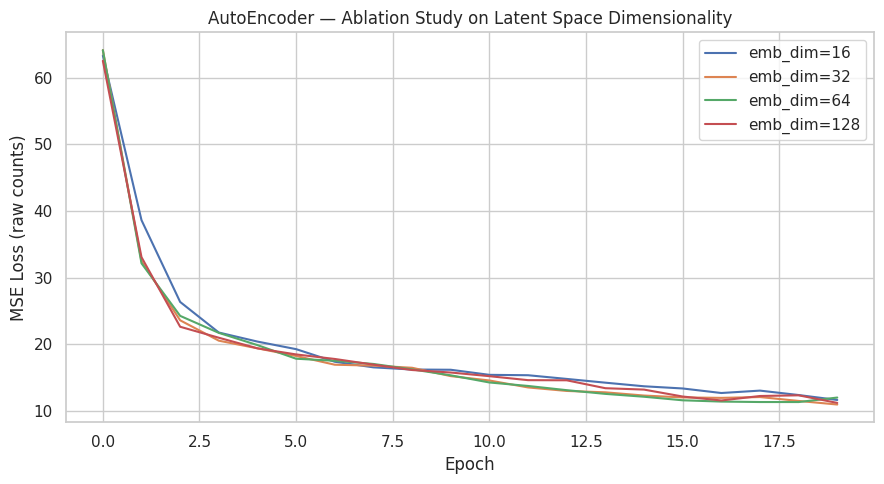

In [14]:
# Visualization: Latent Space Ablation Results
# This plot compares reconstruction loss across different latent dimensions
# (emb_dim ∈ {16, 32, 64, 128}) to evaluate representation capacity.

plt.figure(figsize=(9, 5))
# Plot reconstruction loss for each latent dimension
for ldim in LATENT_SIZES:
    plt.plot(ablation_results[ldim]["losses"], label=f"emb_dim={ldim}")

# Plot formatting
plt.title("AutoEncoder — Ablation Study on Latent Space Dimensionality")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (raw counts)")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / "ae_ablation_latent_size.png")
plt.show()

The ablation study evaluates the impact of latent space dimensionality on reconstruction performance.

From the results, all configurations (16, 32, 64, 128) show a similar decreasing trend in reconstruction loss, indicating stable learning behavior across latent sizes.

However, smaller latent dimensions (e.g., 16) converge slightly slower and achieve higher final reconstruction error, suggesting limited representation capacity.

On the other hand, larger dimensions (64 and 128) provide better reconstruction accuracy but with diminishing returns after a certain point.

Therefore, emb_dim = 64 is selected as a trade-off between compression efficiency and reconstruction performance.

### Selection of Optimal Latent Dimension and Final AutoEncoder Training

The optimal latent dimension (emb_dim = 64) is selected based on the ablation study.

The final AutoEncoder is then trained for 50 epochs using this configuration
to obtain high-quality latent representations for downstream tasks.

In [15]:
# emb_dim=64 : meilleur compromis loss/capacité
emb_dim = 64
print(f"\n→ emb_dim retenu : {emb_dim}")

# --- Entraînement final de l'autoencoder (50 epochs, emb_dim=64) ---
ae      = SiteAutoencoder(input_dim_ae, emb_dim).to(device)
ae_opt  = optim.Adam(ae.parameters(), lr=1e-3)
ae_crit = nn.MSELoss()

train_ae  = torch.tensor(X_sites_train, dtype=torch.float32)
loader_ae = DataLoader(TensorDataset(train_ae), batch_size=256, shuffle=True)

ae_losses = []
for epoch in range(50):
    total_loss = 0.0
    for (xb,) in loader_ae:
        xb = xb.to(device)
        rec, _ = ae(xb)
        loss = ae_crit(rec, xb)
        ae_opt.zero_grad()
        loss.backward()
        ae_opt.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader_ae)
    ae_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"[AE] Epoch {epoch+1}/50  Loss={avg_loss:.4f}")


→ emb_dim retenu : 64
[AE] Epoch 10/50  Loss=14.3621
[AE] Epoch 20/50  Loss=10.9225
[AE] Epoch 30/50  Loss=8.0715
[AE] Epoch 40/50  Loss=7.4764
[AE] Epoch 50/50  Loss=5.9803


### Latent Representation Extraction

The trained encoder is used to extract latent representations (embeddings)
for the training, validation, and test sets.

These embeddings capture behavioral patterns from student–resource interactions
and serve as input features for the downstream classification model.

In [ ]:
# Latent Representation Extraction

# Set the AutoEncoder to evaluation mode
# (disables dropout and batch normalization updates)
ae.eval()

# Disable gradient computation for efficiency
# (no backpropagation needed during inference)
with torch.no_grad():

    # Extract latent embeddings for the training set
    Z_train = ae.encoder(
        torch.tensor(X_sites_train, dtype=torch.float32).to(device)
    ).cpu().numpy()
    # Extract latent embeddings for the validation set
    Z_val   = ae.encoder(
        torch.tensor(X_sites_val,   dtype=torch.float32).to(device)
    ).cpu().numpy()
    # Extract latent embeddings for the test set
    Z_test  = ae.encoder(
        torch.tensor(X_sites_test,  dtype=torch.float32).to(device)
    ).cpu().numpy()
# Display the shape of the learned representations
# (number of samples × embedding dimension)
print(f"Latent embeddings — Train: {Z_train.shape} | "
      f"Val: {Z_val.shape} | Test: {Z_test.shape}")

Latent embeddings — Train: (18251, 64) | Val: (3911, 64) | Test: (3912, 64)


### Normalization of Continuous Features using RobustScaler

Continuous features are scaled using RobustScaler to reduce the impact of outliers.

Categorical features encoded using one-hot encoding are left unchanged,
as they are already represented in a normalized binary format.

In [16]:
# Feature Scaling (Continuous Features Only)

# Initialize RobustScaler
# RobustScaler is used instead of StandardScaler because it is less sensitive
# to outliers (uses median and interquartile range)
scaler = RobustScaler()
# Create copies to avoid modifying original feature matrices
X_feats_train_s = X_feats_train.copy()
X_feats_val_s   = X_feats_val.copy()
X_feats_test_s  = X_feats_test.copy()

# Apply scaling ONLY on continuous features (identified by cont_indices)
# Important: fit on training data, then apply the same transformation to val/test
X_feats_train_s[:, cont_indices] = scaler.fit_transform(
    X_feats_train[:, cont_indices]
)
X_feats_val_s[:, cont_indices]   = scaler.transform(
    X_feats_val[:, cont_indices]
)
X_feats_test_s[:, cont_indices]  = scaler.transform(
    X_feats_test[:, cont_indices]
)
print("RobustScaler is applied only to continuous features. One-hot encoded variables remain in {0,1}.")

RobustScaler is applied only to continuous features. One-hot encoded variables remain in {0,1}.


In [ ]:
# Save baseline features for reproducibility

# These features are used for classical ML baselines.
# They correspond to the tabular representation (without AutoEncoder),
# using the same preprocessing pipeline and data split.

np.savez(
    "baseline_features.npz",
    X_train=X_feats_train_s,
    X_val=X_feats_val_s,
    X_test=X_feats_test_s,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test
)

print("baseline_features.npz saved successfully")

### Feature Fusion (Latent Embeddings + Tabular Features)

The final feature representation is constructed by concatenating latent embeddings
learned by the AutoEncoder with scaled tabular features.

This hybrid representation integrates behavioral patterns with demographic
and academic information, improving the model's predictive capacity.

In [ ]:
# Feature Fusion: Latent Embeddings + Tabular Features

# Concatenate learned latent embeddings (behavioral patterns)
# with scaled tabular features (demographic + academic)

# Training set
X_train_final = np.concatenate(
    [Z_train, X_feats_train_s], axis=1).astype(np.float32)
# Validation set
X_val_final   = np.concatenate(
    [Z_val,   X_feats_val_s],   axis=1).astype(np.float32)
# Test set
X_test_final  = np.concatenate(
    [Z_test,  X_feats_test_s],  axis=1).astype(np.float32)
# Display final feature vector dimensions
# (number of samples × total feature size)
print(f"Final vector dimension — Train: {X_train_final.shape} "
      f"| Val: {X_val_final.shape} | Test: {X_test_final.shape}")

Dimension vecteur final — Train: (18251, 91) | Val: (3911, 91) | Test: (3912, 91)


## Part 3 - Classification Model

### DeepResNet Architecture and Training Setup

The classification model is based on a Deep Residual Network (DeepResNet),
which incorporates skip connections to improve gradient flow and training stability.

The model combines fully connected layers with batch normalization, ReLU activation,
and dropout for regularization.

To handle class imbalance, a weighted cross-entropy loss is used.

The model is optimized using Adam with weight decay for L2 regularization.

In [ ]:
# DeepResNet Classifier

# Deep Residual Network Architecture
# -------------------------------------------------------------------------
# This model is a fully connected Deep Residual Network (ResNet-inspired)
# designed for classification of student outcomes.
#
# The architecture includes:
# - Fully connected layers (feature transformation)
# - Batch Normalization (training stability)
# - ReLU activation (non-linearity)
# - Dropout (regularization)
#
# Residual connection:
# h_{l+1} = g(h_l) + α · W_skip(h_l)
# where:
# - g = FC → BN → ReLU → Dropout
# - α = 0.2 is a fixed scaling factor for the skip connection
#
# This helps:
# - improve gradient flow
# - avoid vanishing gradients
# - stabilize deep network training

class DeepResNet(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.5):
        super().__init__()
        # First transformation block
        self.fc1   = nn.Linear(input_dim, 256)
        self.bn1   = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout(dropout_rate)
        # Second transformation block
        self.fc2   = nn.Linear(256, 128)
        self.bn2   = nn.BatchNorm1d(128)
        self.drop2 = nn.Dropout(dropout_rate)
        # Skip connection (dimension projection)
        self.skip  = nn.Linear(256, 128)
        # Output layer (classification)
        self.out   = nn.Linear(128, num_classes)

    def forward(self, x):
        # First block: feature extraction
        x1 = self.drop1(F.relu(self.bn1(self.fc1(x))))
        # Second block + residual connection
        x2 = self.drop2(F.relu(self.bn2(self.fc2(x1))))
        x  = x2 + 0.2 * self.skip(x1)
        # Output logits
        return self.out(x)

# Model Initialization

# Input dimension = fused feature vector size
input_dim_final = X_train_final.shape[1]
# Number of output classes (multi-class classification)
num_classes     = len(np.unique(y_all))

# Initialize model
model = DeepResNet(input_dim_final, num_classes, dropout_rate=0.5).to(device)

# Loss Function (Class Imbalance Handling)

# Compute class weights to address imbalanced class distribution
cls_w = compute_class_weight(
    "balanced", classes=np.unique(y_train), y=y_train)
# Convert to tensor for PyTorch
cls_w = torch.tensor(cls_w, dtype=torch.float32).to(device)

# Weighted CrossEntropy Loss
criterion = nn.CrossEntropyLoss(weight=cls_w)

# Optimizer Configuration
# Adam optimizer with:
# - low learning rate (stable training)
# - weight decay (L2 regularization)
optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=5e-3)

# Data Loaders

# Training DataLoader (shuffled for stochastic learning)
train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train_final),
        torch.tensor(y_train)
    ),
    batch_size=128,
    shuffle=True
)

# Validation DataLoader (no shuffle for evaluation consistency)
val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val_final),
        torch.tensor(y_val)
    ),
    batch_size=256,
    shuffle=False
)

### Training Strategy with Regularization and Early Stopping

The model is trained using a supervised learning approach with mini-batch gradient descent.

Training performance is monitored on a validation set at each epoch using both loss and accuracy metrics.

Early stopping is applied to prevent overfitting by stopping training when the validation loss does not improve for a fixed number of epochs (patience = 7).

The best model (based on validation loss) is saved and restored after training.

In [ ]:
# Model Training with Validation Monitoring and Early Stopping

# Lists used to store training and validation history
# These values will be used later to plot learning curves
train_losses     = []
train_accs       = []
val_losses       = []
val_accs         = []
# Variables used for early stopping
# best_val_loss stores the lowest validation loss observed during training
best_val_loss    = float('inf')
best_model_wts   = None

# Early stopping patience:
# training stops if validation loss does not improve for 7 consecutive epochs
patience         = 7
patience_counter = 0

# Maximum number of training epochs
for epoch in range(100):
    # Training Phase

    # Set model to training mode
    # This enables dropout and batch normalization updates
    model.train()
    total_loss = 0.0
    correct    = 0

    for xb, yb in train_loader:
        # Move data to CPU/GPU device
        xb, yb = xb.to(device), yb.to(device)
        # Reset gradients before each update
        optimizer.zero_grad()
        # Forward pass
        out  = model(xb)
        # Compute weighted cross-entropy loss
        loss = criterion(out, yb)
        # Backpropagation and parameter update
        loss.backward()
        optimizer.step()
        # Accumulate training loss and correct predictions
        total_loss += loss.item()
        correct    += (out.argmax(1) == yb).sum().item()

    # Compute average training loss and accuracy
    avg_train_loss = total_loss / len(train_loader)
    train_acc      = correct / len(y_train)
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # Validation Phase

    # Set model to evaluation mode
    # This disables dropout and stops batch normalization updates
    model.eval()
    val_loss    = 0.0
    val_correct = 0
    # Disable gradient computation during validation
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            # Forward pass
            out  = model(xb)
            # Compute validation loss
            loss = criterion(out, yb)
            # Accumulate validation loss and correct predictions
            val_loss    += loss.item()
            val_correct += (out.argmax(1) == yb).sum().item()

    # Compute average validation loss and accuracy
    avg_val_loss = val_loss / len(val_loader)
    val_acc      = val_correct / len(y_val)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}  "
              f"Train Loss={avg_train_loss:.4f}  Train Acc={train_acc:.4f}  |  "
              f"Val Loss={avg_val_loss:.4f}  Val Acc={val_acc:.4f}")

    # Early Stopping
    # Save the model weights when validation loss improves
    if avg_val_loss < best_val_loss:
        best_val_loss  = avg_val_loss
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    # If validation loss does not improve, increase patience counter
    else:
        patience_counter += 1
        # Stop training when patience limit is reached
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} "
                  f"(val_loss has been stable for {patience} epochs)")
            break

# Restore the best model weights based on validation loss
model.load_state_dict(best_model_wts)
print(f"Best weights restored (best val_loss={best_val_loss:.4f})")

Epoch   5  Train Loss=1.1068  Train Acc=0.4464  |  Val Loss=1.0558  Val Acc=0.4725
Epoch  10  Train Loss=1.0026  Train Acc=0.4999  |  Val Loss=0.9500  Val Acc=0.5548
Epoch  15  Train Loss=0.8014  Train Acc=0.6168  |  Val Loss=0.6985  Val Acc=0.7313
Epoch  20  Train Loss=0.5755  Train Acc=0.7397  |  Val Loss=0.4548  Val Acc=0.8737
Epoch  25  Train Loss=0.4450  Train Acc=0.8149  |  Val Loss=0.3194  Val Acc=0.9269
Epoch  30  Train Loss=0.3572  Train Acc=0.8581  |  Val Loss=0.2200  Val Acc=0.9537
Epoch  35  Train Loss=0.2900  Train Acc=0.8929  |  Val Loss=0.1556  Val Acc=0.9657
Epoch  40  Train Loss=0.2452  Train Acc=0.9136  |  Val Loss=0.1326  Val Acc=0.9778
Epoch  45  Train Loss=0.2299  Train Acc=0.9208  |  Val Loss=0.0990  Val Acc=0.9826
Epoch  50  Train Loss=0.1895  Train Acc=0.9340  |  Val Loss=0.0786  Val Acc=0.9847
Epoch  55  Train Loss=0.1705  Train Acc=0.9442  |  Val Loss=0.0631  Val Acc=0.9877
Epoch  60  Train Loss=0.1677  Train Acc=0.9449  |  Val Loss=0.0635  Val Acc=0.9921
Epoc

### Training and Validation Loss Curves (Classifier)

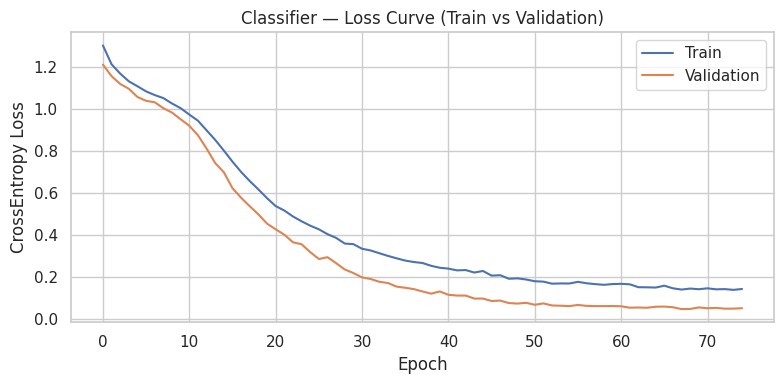

In [ ]:
# Training vs Validation Loss Curves

# This plot shows the evolution of the Cross-Entropy loss during training.
# - The training loss reflects how well the model fits the training data.
# - The validation loss reflects the model's generalization ability.

# Plot training loss across epochs
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train")
# Plot validation loss across epochs
plt.plot(val_losses,   label="Validation")
# Figure title
plt.title("Classifier — Loss Curve (Train vs Validation)")
# Axis labels
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
# Display legend (Train vs Validation)
plt.legend()
# Improve layout for publication quality
plt.tight_layout()
# Save figure for reproducibility and paper inclusion
plt.savefig(out_dir / "clf_loss_curve.png")
# Display plot
plt.show()

The training and validation loss curves show a consistent decrease over epochs, indicating that the model successfully learns meaningful patterns from the data.

The validation loss closely follows the training loss and remains slightly lower throughout training, suggesting that the model generalizes well and does not suffer from overfitting.

The absence of divergence between the two curves confirms the effectiveness of the regularization techniques applied (dropout and L2 regularization).

Overall, the model demonstrates stable convergence and strong generalization performance.

### Convergence Analysis of the AutoEncoder Training (Loss Curve)

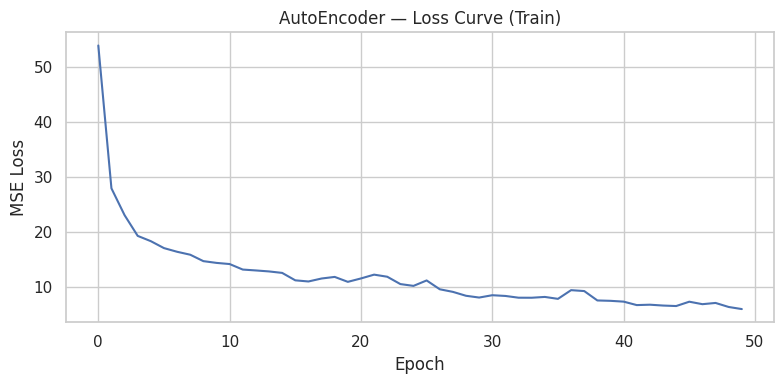

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(ae_losses)
plt.title("AutoEncoder — Loss Curve (Train)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.savefig(out_dir / "ae_loss_curve.png")
plt.show()

The training loss curve shows a rapid decrease in the early epochs,
followed by a gradual stabilization, indicating effective learning and convergence.

The model quickly captures the main structure of the data, and the slower decrease
in later epochs suggests fine-tuning of the learned representation.

No significant oscillations or divergence are observed, confirming stable training behavior.

### Training and Validation Accuracy Curves (Classifier)

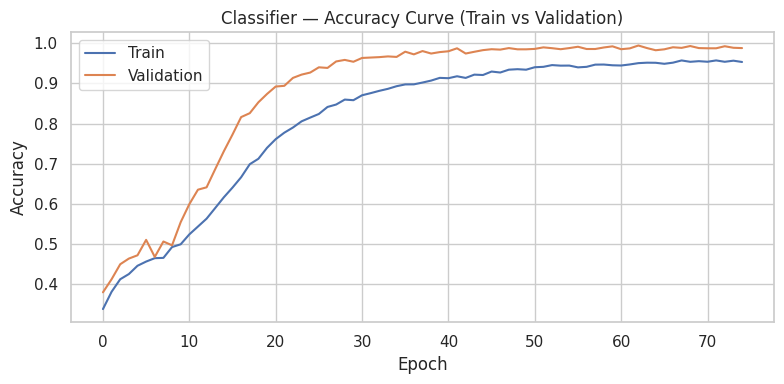

In [ ]:
# Training vs Validation Accuracy Curves

# This plot illustrates the evolution of model accuracy during training.
# - Training accuracy measures how well the model fits the training data.
# - Validation accuracy evaluates the model's generalization ability on unseen data.
plt.figure(figsize=(8, 4))
# Plot training accuracy across epochs
plt.plot(train_accs, label="Train")
# Plot validation accuracy across epochs
plt.plot(val_accs,   label="Validation")
# Figure title
plt.title("Classifier — Accuracy Curve (Train vs Validation)")
# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
# Add legend to distinguish curves
plt.legend()
# Adjust layout for better visualization
plt.tight_layout()
# Save figure for reproducibility and publication
plt.savefig(out_dir / "clf_acc_curve.png")
# Display the plot
plt.show()

The training and validation accuracy curves show a consistent upward trend, indicating that the model progressively improves its predictive performance over epochs.

The validation accuracy closely follows — and even slightly exceeds — the training accuracy throughout the training process. This behavior suggests that the model generalizes well and benefits from regularization techniques such as dropout and weight decay.

The absence of a significant gap between the two curves indicates that overfitting is effectively controlled. Moreover, the stabilization of both curves at high accuracy values confirms that the model has reached convergence.

Overall, these results demonstrate that the proposed model achieves strong generalization performance on unseen data.

## Part 4 - Evaluation

### Final Model Evaluation on Test Set

The trained model is evaluated on the held-out test set to assess its generalization performance.

Predicted class probabilities are obtained using a softmax function, and final predictions are derived by selecting the class with the highest probability.

Standard classification metrics, including accuracy and detailed classification report (precision, recall, F1-score), are computed.

In [ ]:
# Final Model Evaluation on Test Set

# The trained model is evaluated on the held-out test set to assess its
# generalization performance on unseen data.

# Set the model to evaluation mode
# This disables dropout and batch normalization updates
model.eval()

# Disable gradient computation for efficiency during inference
with torch.no_grad():
    # Forward pass: compute raw outputs (logits)
    logits = model(torch.tensor(X_test_final).to(device))
    # Convert logits to probabilities using softmax
    # Each row represents the probability distribution over classes
    probas = torch.softmax(logits, dim=1).cpu().numpy()
    # Obtain predicted class labels by selecting the class with maximum probability
    preds  = probas.argmax(axis=1)

# Performance Metrics

# Compute overall classification accuracy on the test set
print(f"\nAccuracy (test) : {accuracy_score(y_test, preds):.4f}")

# Display detailed classification report:
# - Precision: correctness of positive predictions
# - Recall: ability to find all positive instances
# - F1-score: harmonic mean of precision and recall
print(classification_report(y_test, preds, digits=4))


Accuracy (test) : 0.9888
              precision    recall  f1-score   support

           0     0.9970    0.9970    0.9970       999
           1     0.9966    0.9854    0.9910       891
           2     0.9932    0.9828    0.9879      1625
           3     0.9363    1.0000    0.9671       397

    accuracy                         0.9888      3912
   macro avg     0.9808    0.9913    0.9858      3912
weighted avg     0.9892    0.9888    0.9888      3912



The model achieves an overall accuracy of 98.88% on the test set, indicating excellent predictive performance and strong generalization capability.

Class-wise analysis shows that the model performs consistently well across all categories. Classes 0 (Withdrawn), 1 (Fail), and 2 (Pass) exhibit very high precision and recall values (above 98%), demonstrating reliable classification.

Class 3 (Distinction) achieves perfect recall (1.0000), meaning that all instances of this class are correctly identified. However, its precision is slightly lower (0.9363), suggesting that a small number of samples from other classes are incorrectly predicted as Distinction.

The macro-average F1-score (0.9858) and weighted-average F1-score (0.9888) confirm that the model maintains balanced performance across both majority and minority classes.

Overall, these results demonstrate that the proposed hybrid AutoEncoder–DeepResNet model is highly effective for predicting student academic outcomes, with strong robustness across different performance categories.

### Confusion Matrix Analysis on the Test Set

The confusion matrix provides a detailed view of class-wise prediction performance,
highlighting correct classifications as well as misclassification patterns between classes.

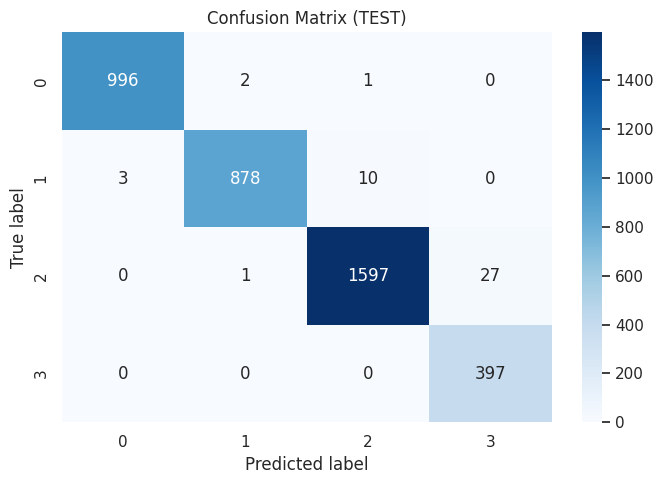

In [ ]:
# Confusion Matrix Visualization

# The confusion matrix provides a detailed view of the model's predictions
# by comparing true labels against predicted labels.
# It helps identify correct classifications and misclassification patterns.

# Compute confusion matrix
cm = confusion_matrix(y_test, preds)
# Plot heatmap for better visualization
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# Add titles and axis labels
plt.title("Confusion Matrix (TEST)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
# Improve layout and save figure
plt.tight_layout()
plt.savefig(out_dir / "confusion_matrix.png")
# Display the plot
plt.show()

### Receiver Operating Characteristic (ROC) Analysis for Multiclass Classification

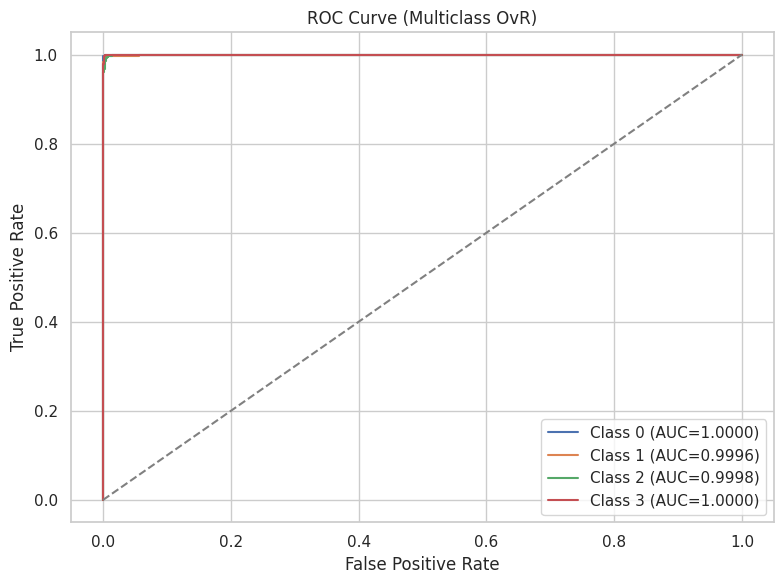

Macro   ROC-AUC (OvR) : 0.9998
Weighted ROC-AUC (OvR): 0.9998


In [ ]:
# Multiclass ROC Curve Analysis (One-vs-Rest)

# This section evaluates the model's ability to discriminate between classes
# using ROC curves in a multiclass setting.
# A One-vs-Rest (OvR) strategy is applied, where each class is evaluated
# against all other classes.

# Extract unique class labels
classes    = np.unique(y_all)

# Binarize the test labels for multiclass ROC computation
# Each class is converted into a binary problem
y_test_bin = label_binarize(y_test, classes=classes)

# Initialize plot
plt.figure(figsize=(8, 6))
# Compute ROC curve and AUC for each class
for i, c in enumerate(classes):
    # Compute False Positive Rate (FPR) and True Positive Rate (TPR)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probas[:, i])
    # Compute Area Under the Curve (AUC)
    roc_auc     = auc(fpr, tpr)
    # Plot ROC curve for current class
    plt.plot(fpr, tpr, label=f"Class {c} (AUC={roc_auc:.4f})")


# Plot diagonal line (random classifier baseline)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
# Add titles and labels
plt.title("ROC Curve (Multiclass OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# Show legend
plt.legend()
# Adjust layout and save figure
plt.tight_layout()
plt.savefig(out_dir / "roc_curve.png")
# Display plot
plt.show()

# Global Performance Metrics

# Macro-average ROC-AUC (equal weight to all classes)
macro_roc_auc    = roc_auc_score(
    y_test_bin, probas, average="macro",    multi_class="ovr")
# Weighted-average ROC-AUC (weighted by class frequency)
weighted_roc_auc = roc_auc_score(
    y_test_bin, probas, average="weighted", multi_class="ovr")
# Print results
print(f"Macro   ROC-AUC (OvR) : {macro_roc_auc:.4f}")
print(f"Weighted ROC-AUC (OvR): {weighted_roc_auc:.4f}")

The ROC curves demonstrate an excellent discriminative ability of the model across all classes.

All classes achieve near-perfect AUC values (close to 1.0), indicating that the model can almost perfectly distinguish each class from the others.

The curves are tightly concentrated near the top-left corner of the plot, which corresponds to a high true positive rate (TPR) and a very low false positive rate (FPR). This reflects excellent classification performance.

The macro-average ROC-AUC (0.9998) confirms that the model performs consistently well across all classes, regardless of class imbalance. Similarly, the weighted-average ROC-AUC (0.9998) indicates that overall performance remains extremely high when accounting for class distribution.

These results demonstrate that the proposed hybrid AutoEncoder–DeepResNet architecture provides exceptional class separability and robust predictive capability.

Such near-perfect ROC-AUC scores highlight the effectiveness of combining behavioral embeddings with tabular features for modeling student academic outcomes.

### Precision–Recall Analysis for Multiclass Classification

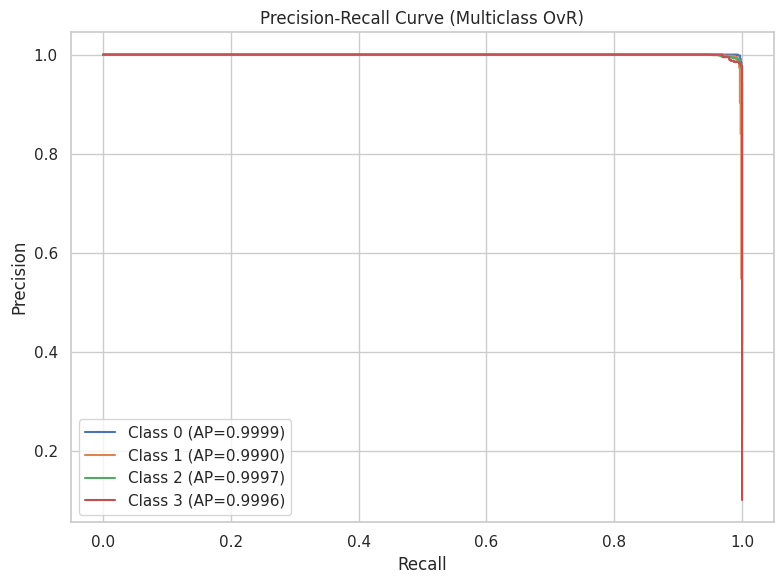

Macro Average Precision (OvR) : 0.9996


In [ ]:
# Multiclass Precision–Recall Curve Analysis (One-vs-Rest)

# This section evaluates the model's performance using Precision–Recall curves.
# It is particularly useful in imbalanced classification settings,
# as it focuses on the trade-off between precision and recall.

# Initialize figure
plt.figure(figsize=(8, 6))
# List to store Average Precision (AP) for each class
ap_scores = []

# Compute Precision–Recall curve for each class (One-vs-Rest)
for i, c in enumerate(classes):
    # Compute precision and recall values
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i], probas[:, i])
    # Compute Average Precision (area under PR curve)
    ap = average_precision_score(y_test_bin[:, i], probas[:, i])
    # Store AP score
    ap_scores.append(ap)
    # Plot Precision–Recall curve
    plt.plot(recall, precision, label=f"Class {c} (AP={ap:.4f})")

# Add plot title and axis labels
plt.title("Precision-Recall Curve (Multiclass OvR)")
plt.xlabel("Recall")
plt.ylabel("Precision")
# Display legend
plt.legend()
# Improve layout and save figure
plt.tight_layout()
plt.savefig(out_dir / "precision_recall_curve.png")
# Show plot
plt.show()

# Compute macro-average Average Precision across all classes
print(f"Macro Average Precision (OvR) : {np.mean(ap_scores):.4f}")

The Precision–Recall curves indicate outstanding model performance across all classes.

All classes achieve extremely high Average Precision (AP) scores (close to 1.0), demonstrating that the model maintains both high precision and high recall simultaneously.

The curves remain close to the top-right corner of the plot, which reflects an optimal balance between correctly identifying positive instances (high recall) and minimizing false positives (high precision).

The macro-average precision score (0.9996) confirms that the model performs consistently well across all classes, including minority categories.

These results are particularly significant in the context of educational data, where class imbalance may exist, and accurate identification of all student categories is critical.

Overall, the Precision–Recall analysis further validates the robustness and reliability of the proposed hybrid AutoEncoder–DeepResNet model.

### Distribution of Prediction Confidence (Max Probabilities)

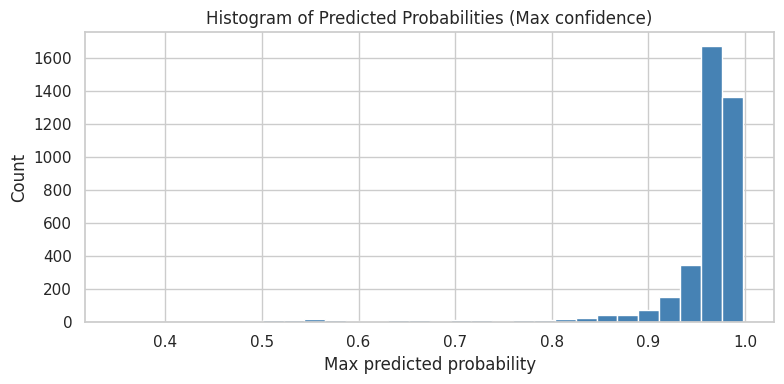


=== Pipeline terminé. Graphiques sauvegardés dans: eda_outputs ===


In [ ]:
# Model Confidence Analysis

# This section analyzes the confidence of the model's predictions
# by examining the distribution of the maximum predicted probability
# for each sample.

# Extract the maximum predicted probability per sample
# (i.e., confidence of the predicted class)
max_probas = probas.max(axis=1)

# Plot histogram of prediction confidence
plt.figure(figsize=(8, 4))
plt.hist(max_probas, bins=30, color="steelblue", edgecolor="white")

# Titles and labels
plt.title("Histogram of Predicted Probabilities (Max confidence)")
plt.xlabel("Max predicted probability")
plt.ylabel("Count")

# Improve layout and save figure
plt.tight_layout()
plt.savefig(out_dir / "hist_max_proba.png")
# Display plot
plt.show()

print("\n=== Pipeline completed. Plots saved in:", out_dir, "===")

The histogram shows that the majority of predicted probabilities are highly concentrated near 1.0, indicating that the model makes predictions with very high confidence.

This suggests that the model has learned highly discriminative representations and is able to clearly separate the different classes.

Only a small number of samples exhibit lower confidence (below 0.9), which may correspond to more ambiguous or borderline cases.

Overall, the distribution reflects a strong and consistent decision behavior, reinforcing the reliability of the model.

However, such high confidence levels across most predictions may also indicate potential overconfidence, which should be carefully considered, especially in real-world deployment scenarios.

### Model Persistence and Experimental Reproducibility

In [ ]:
# 19. Model Saving and Reproducibility

# This section saves all components of the pipeline to ensure full reproducibility.
# It allows reloading the trained models and preprocessing steps without retraining.

import os

# Create directory for saving all artifacts
save_dir = Path("saved_model")
save_dir.mkdir(exist_ok=True)

# Save model weights
# Only the learned parameters are saved.
# This is the preferred method for deployment and reproducibility.
torch.save(model.state_dict(), save_dir / "deepresnet_weights.pth")
print("Saved model weights → saved_model/deepresnet_weights.pth")

# Save full model (architecture + weights)

# This allows reloading the entire model directly,
# but is less flexible than saving only weights.
torch.save(model, save_dir / "deepresnet_full_model.pth")
print("Complete model saved   → saved_model/deepresnet_full_model.pth")

# Save AutoEncoder weights
# The AutoEncoder is required to reproduce latent representations (embeddings).
torch.save(ae.state_dict(), save_dir / "autoencoder_weights.pth")
print("Saved model weights      → saved_model/autoencoder_weights.pth")

# Save preprocessing scaler

# The scaler must be saved to ensure consistent feature normalization
# during inference or future experiments.

import joblib
joblib.dump(scaler, save_dir / "robust_scaler.pkl")
print("RobustScaler saved     → saved_model/robust_scaler.pkl")

# Save metadata

# Metadata contains all key experimental parameters needed
# to reproduce the model configuration.

import json
metadata = {
    "model_architecture": "DeepResNet",
    "input_dim"         : int(input_dim_final),
    "num_classes"       : int(num_classes),
    "dropout_rate"      : 0.5,
    "emb_dim"           : int(emb_dim),
    "split"             : "70/15/15",
    "seed"              : SEED,
    "label_map"         : {"Withdrawn": 0, "Fail": 1,
                           "Pass": 2, "Distinction": 3},
    "continuous_cols"   : CONTINUOUS_COLS,
    "best_val_loss"     : round(float(best_val_loss), 6),
}
with open(save_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)
print("Metadata saved    → saved_model/metadata.json")

print(f"\n=== All files saved in : {save_dir} ===")

✓ Poids du modèle sauvegardés → saved_model/deepresnet_weights.pth
✓ Modèle complet sauvegardé   → saved_model/deepresnet_full_model.pth
✓ Autoencoder sauvegardé      → saved_model/autoencoder_weights.pth
✓ RobustScaler sauvegardé     → saved_model/robust_scaler.pkl
✓ Métadonnées sauvegardées    → saved_model/metadata.json

=== Tous les fichiers sauvegardés dans : saved_model ===


### Model Reloading

In [16]:
# Model Reloading for Inference and Reuse

# Reload DeepResNet model
# Recreate the model architecture with the same configuration
# and load the trained weights from disk.

model_loaded = DeepResNet(input_dim_final, num_classes, dropout_rate=0.5)
model_loaded.load_state_dict(
    torch.load("saved_model/deepresnet_weights.pth",
               map_location=device))
# Move model to the appropriate device (CPU or GPU)
model_loaded.to(device)

# Set model to evaluation mode (important: disables dropout, etc.)
model_loaded.eval()
print("Model successfully reloaded")


# Reload AutoEncoder

# The AutoEncoder is required to generate latent embeddings
# from student–resource interaction data during inference.

ae_loaded = SiteAutoencoder(input_dim_ae, emb_dim)
ae_loaded.load_state_dict(
    torch.load("Autoencoder saved/autoencoder_weights.pth",
               map_location=device))

# Move to device and set to evaluation mode
ae_loaded.to(device)
ae_loaded.eval()
print("Autoencoder successfully reloaded")

# Reload preprocessing scaler

# The scaler ensures that new input data is normalized
# in the same way as during training.
scaler_loaded = joblib.load("saved_model/robust_scaler.pkl")
print("Scaler successfully reloaded")

### Performance Comparison with State-of-the-Art Approaches on OULAD Dataset

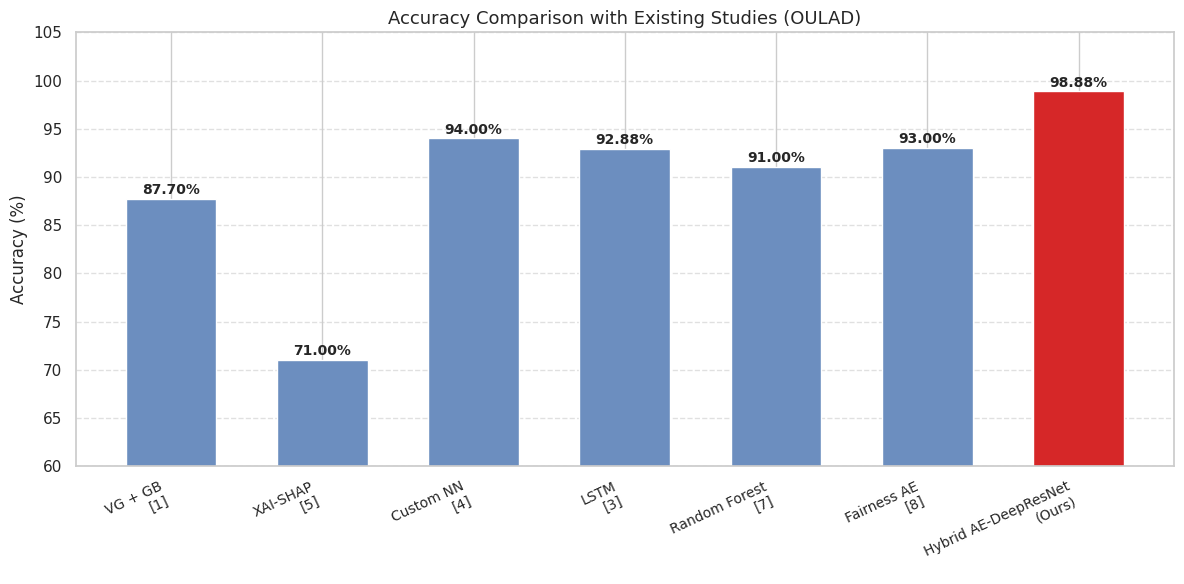

In [ ]:
import matplotlib.pyplot as plt

models = [
    "VG + GB\n[1]",
    "XAI-SHAP\n[5]",
    "Custom NN\n[4]",
    "LSTM\n[3]",
    "Random Forest\n[7]",
    "Fairness AE\n[8]",
    "Hybrid AE-DeepResNet\n(Ours)"
]

accuracy = [87.7, 71.0, 94.0, 92.88, 91.0, 93.0, 98.88]

colors = ["#6c8ebf"] * 6 + ["#d62728"]

plt.figure(figsize=(12, 6))
bars = plt.bar(models, accuracy, color=colors,
               edgecolor='white', width=0.6)

plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Accuracy Comparison with Existing Studies (OULAD)",
          fontsize=13)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.ylim(60, 105)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.5,
             f'{yval:.2f}%',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(out_dir / "comparison_accuracy.png", dpi=300)
plt.show()